# Data Loading, EDA, Outlier Detection & Preprocessing
**Walmart Store Sales Forecasting**

---
### Outline
1. Imports
2. Data Loading
3. Basic EDA (head, info, describe, shape)
4. Missing Values & Duplicates
5. Outlier Detection (IsolationForest + DBSCAN → intersection)
6. Visualisations
7. Feature Engineering function
8. Train / Test split → Encoding & Scaling (no leakage)
9. Save processed data


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set(style='whitegrid', font_scale=1.1)

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Data Loading

In [5]:
train_raw  = pd.read_csv(r"C:\Users\User\Desktop\project\Data sets/raw\train.csv", low_memory=True)
test_raw   = pd.read_csv(r"C:\Users\User\Desktop\project\Data sets/raw\test.csv", low_memory=True)
features   = pd.read_csv(r"C:\Users\User\Desktop\project\Data sets/raw\features.csv", low_memory=True)
stores     = pd.read_csv(r"C:\Users\User\Desktop\project\Data sets/raw\stores.csv", low_memory=True)

print('Dataset Shapes')
print(f'Train : {train_raw.shape}')
print(f'Test : {test_raw.shape}')
print(f'Features : {features.shape}')
print(f'Stores : {stores.shape}')

Dataset Shapes
Train : (421570, 5)
Test : (115064, 4)
Features : (8190, 12)
Stores : (45, 3)


In [39]:
# Merge datasets
feature_store = features.merge(stores, on='Store', how='inner')

for df in [train_raw, test_raw, feature_store]:
    df['Date'] = pd.to_datetime(df['Date'])

train_df = (train_raw.merge(feature_store, on=['Store', 'Date', 'IsHoliday'], how='inner').sort_values(['Store', 'Dept', 'Date']) .reset_index(drop=True))

test_df  = (test_raw.merge(feature_store, on=['Store', 'Date', 'IsHoliday'], how='inner').sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True))

print(f'Merged Train shape : {train_df.shape}')
print(f'Merged Test shape  : {test_df.shape}')

Merged Train shape : (421570, 16)
Merged Test shape  : (115064, 15)


## 3. Basic EDA

In [40]:
print("Head of Train Data")
display(train_df.head())

print("\nTail of Train Data")
display(train_df.tail())

Head of Train Data


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315



Tail of Train Data


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221
421569,45,98,2012-10-26,1076.80,False,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,B,118221


In [41]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [42]:
numeric_df = train_df.select_dtypes(include=[np.number])
numeric_df.describe().T.style.background_gradient(subset=['std'], cmap='Reds').set_caption('Descriptive Statistics')

,count,mean,std,min,25%,50%,75%,max
Store,421570.000000,22.200546,12.785297,1.000000,11.000000,22.000000,33.000000,45.000000
Dept,421570.000000,44.260317,30.492054,1.000000,18.000000,37.000000,74.000000,99.000000
Weekly_Sales,421570.000000,15981.258123,22711.183519,-4988.940000,2079.650000,7612.030000,20205.852500,693099.360000
Temperature,421570.000000,60.090059,18.447931,-2.060000,46.680000,62.090000,74.280000,100.140000
Fuel_Price,421570.000000,3.361027,0.458515,2.472000,2.933000,3.452000,3.738000,4.468000
MarkDown1,150681.000000,7246.420196,8291.221345,0.270000,2240.270000,5347.450000,9210.900000,88646.760000
MarkDown2,111248.000000,3334.628621,9475.357325,-265.760000,41.600000,192.000000,1926.940000,104519.540000
MarkDown3,137091.000000,1439.421384,9623.078290,-29.100000,5.080000,24.600000,103.990000,141630.610000
MarkDown4,134967.000000,3383.168256,6292.384031,0.220000,504.220000,1481.310000,3595.040000,67474.850000
MarkDown5,151432.000000,4628.975079,5962.887455,135.160000,1878.440000,3359.450000,5563.800000,108519.280000


In [43]:
for col in train_df.select_dtypes(include=[np.number]):
    print(f'  {col:<15} {train_df[col].skew():.4f}')

  Store           0.0778
  Dept            0.3582
  Weekly_Sales    3.2620
  Temperature     -0.3214
  Fuel_Price      -0.1049
  MarkDown1       3.3418
  MarkDown2       5.4413
  MarkDown3       8.3995
  MarkDown4       4.8475
  MarkDown5       8.1699
  CPI             0.0852
  Unemployment    1.1837
  Size            -0.3258


## 4. Missing Values & Duplicates

,Missing Count,Missing %
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08


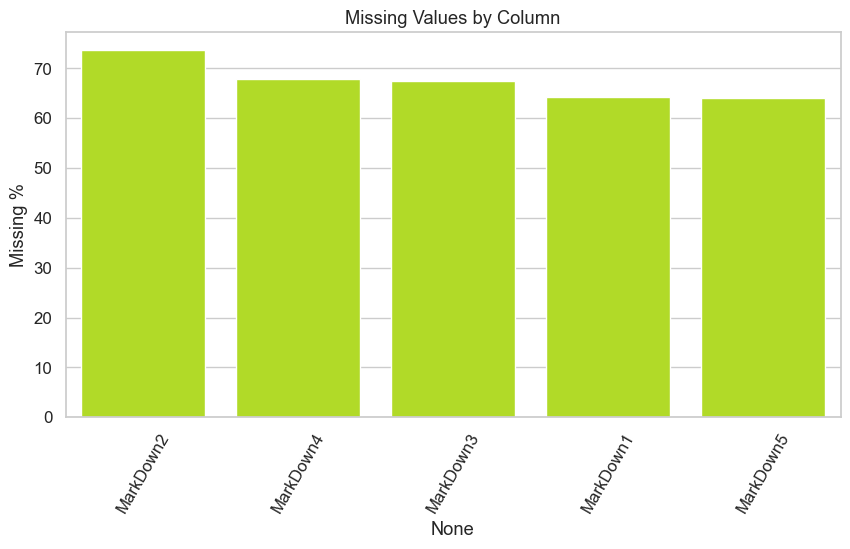

In [44]:
missing = train_df.isnull().sum()
missing_pct = (train_df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

display(missing_df)

# visualise
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Missing %'], color='#C1F80A')
plt.xticks(rotation=60)
plt.title('Missing Values by Column')
plt.ylabel('Missing %')
plt.savefig(r'C:\Users\User\Desktop\project\imgs\fig_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

In [45]:
dup_count = train_df.duplicated().sum()
print(f'Duplicate rows : {dup_count}')

Duplicate rows : 0


## 5. Outlier Detection — IsolationForest ∩ LOF

In [46]:
# Use Weekly_Sales as the univariate signal for outlier detection
outlier_col = 'Weekly_Sales'
outlier_col = train_df[[outlier_col]].copy()

scaler = StandardScaler()
outlier_col_scaled = scaler.fit_transform(outlier_col)

# 1.IsolationForest
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(outlier_col)

iso_outlier = iso_labels == -1
print(f'IsolationForest detected : {iso_outlier.sum()} outliers')

# 2. LOF
lof = LocalOutlierFactor(n_neighbors=25, contamination=0.05)
lof_labels = lof.fit_predict(outlier_col_scaled)
lof_outlier = lof_labels == -1
print(f'LOF detected: {lof_outlier.sum()} outliers')

# Intersection
Intersection = iso_outlier & lof_outlier
print(f'Intersection outliers : {Intersection.sum()} outliers')


IsolationForest detected : 21075 outliers
LOF detected: 21079 outliers
Intersection outliers : 433 outliers


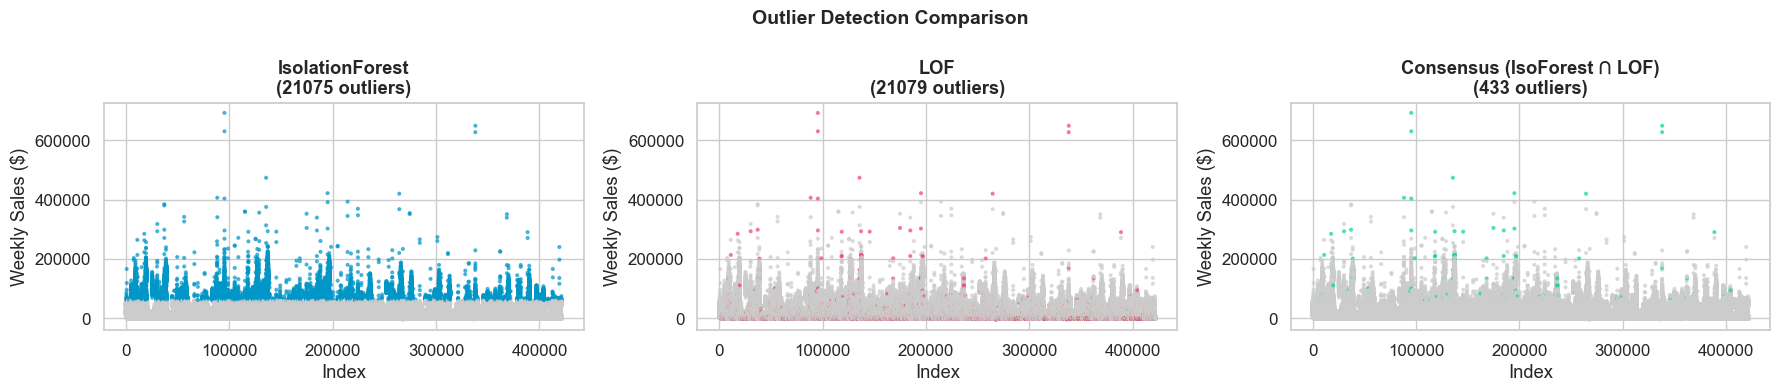

In [47]:
# Visualise outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, mask, title, color in zip(axes,[iso_outlier, lof_outlier, Intersection],['IsolationForest', 'LOF', 'Consensus (IsoForest ∩ LOF)'],['#0096C7', '#EF476F', '#06D6A0']):
    ax.scatter(range(len(train_df)),train_df['Weekly_Sales'], c=np.where(mask, color, '#CCCCCC'),s=4, alpha=0.6)
    ax.set_title(f'{title}\n({mask.sum()} outliers)', fontweight='bold')
    ax.set_xlabel('Index')
    ax.set_ylabel('Weekly Sales ($)')

plt.suptitle('Outlier Detection Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs\fig_outlier_detection.png', dpi=120, bbox_inches='tight')
plt.show()

# # Remove Intersection outliers
# train_df = train_df[~Intersection].reset_index(drop=True)
# print(f'Train shape after outlier removal : {train_df.shape}')


## 6. Visualisations

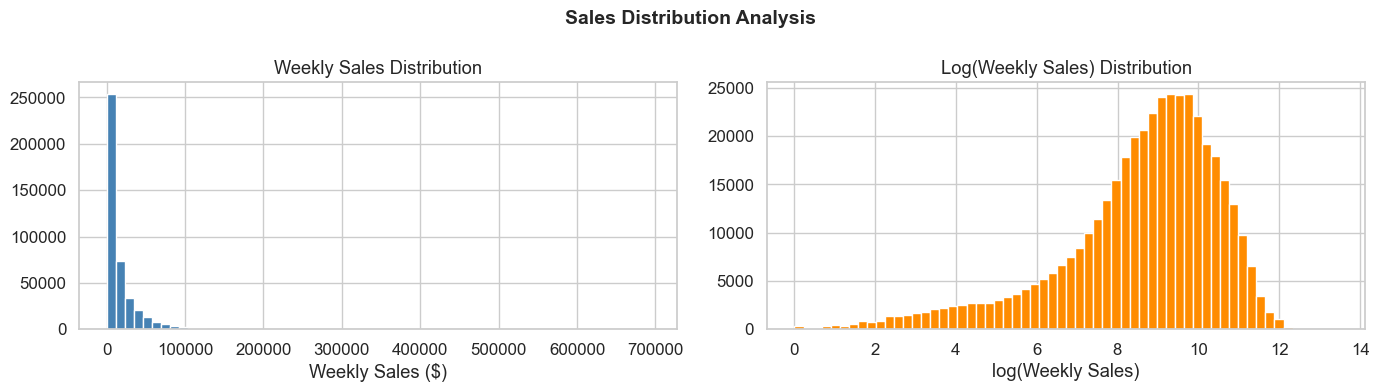

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sales = train_df['Weekly_Sales']
sales = sales[sales > 0]
log_sales = np.log1p(sales)

axes[0].hist(sales, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Weekly Sales Distribution')
axes[0].set_xlabel('Weekly Sales ($)')

axes[1].hist(log_sales, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Log(Weekly Sales) Distribution')
axes[1].set_xlabel('log(Weekly Sales)')

plt.suptitle('Sales Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs\fig_sales_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [49]:
train_df['Year']  = train_df['Date'].dt.year
train_df['Month'] = train_df['Date'].dt.month

df_weekly = train_df.groupby('Date')['Weekly_Sales'].sum().reset_index()
fig = px.line(df_weekly, x='Date', y='Weekly_Sales', title='Total Weekly Sales Over Time', labels={'Weekly_Sales': 'Total Sales ($)', 'Date': 'Date'}, template='plotly_white')
fig.update_traces(line_color='royalblue', line_width=2)
fig.show()

In [50]:
monthly = train_df.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()
fig = px.line(monthly, x='Month', y='Weekly_Sales', animation_frame='Year', title='Monthly Average Weekly Sales Evolution',labels={'Weekly_Sales': 'Mean Weekly Sales ($)'})
fig.update_layout(xaxis=dict(tickmode='linear', dtick=1))
fig.show()

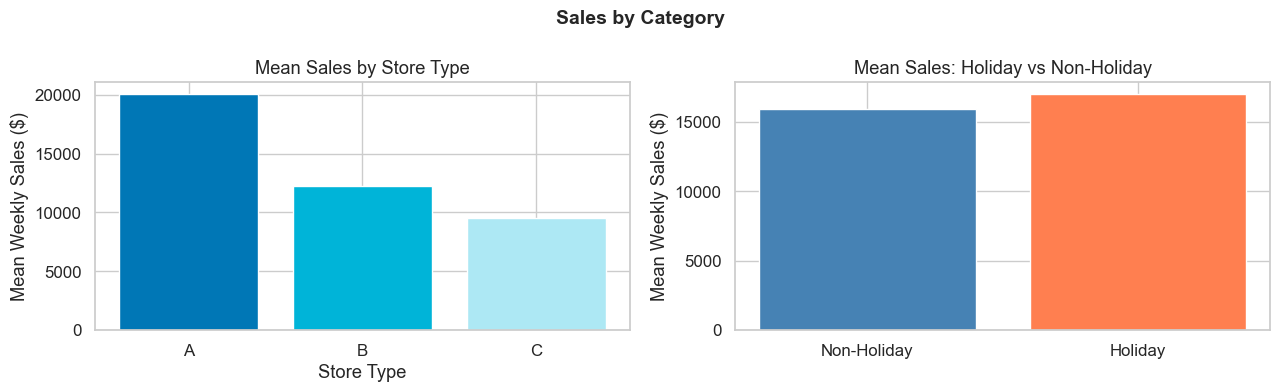

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sales by Store Type
type_sales = train_df.groupby('Type')['Weekly_Sales'].mean()
axes[0].bar(type_sales.index, type_sales.values, color=['#0077B6', '#00B4D8', '#ADE8F4'], edgecolor='white')
axes[0].set_title('Mean Sales by Store Type')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Mean Weekly Sales ($)')

# Sales by Holiday
holiday_sales = train_df.groupby('IsHoliday')['Weekly_Sales'].mean()
axes[1].bar(['Non-Holiday', 'Holiday'], holiday_sales.values, color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Mean Sales: Holiday vs Non-Holiday')
axes[1].set_ylabel('Mean Weekly Sales ($)')

plt.suptitle('Sales by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs\fig_sales_by_type_holiday.png', dpi=120, bbox_inches='tight')
plt.show()

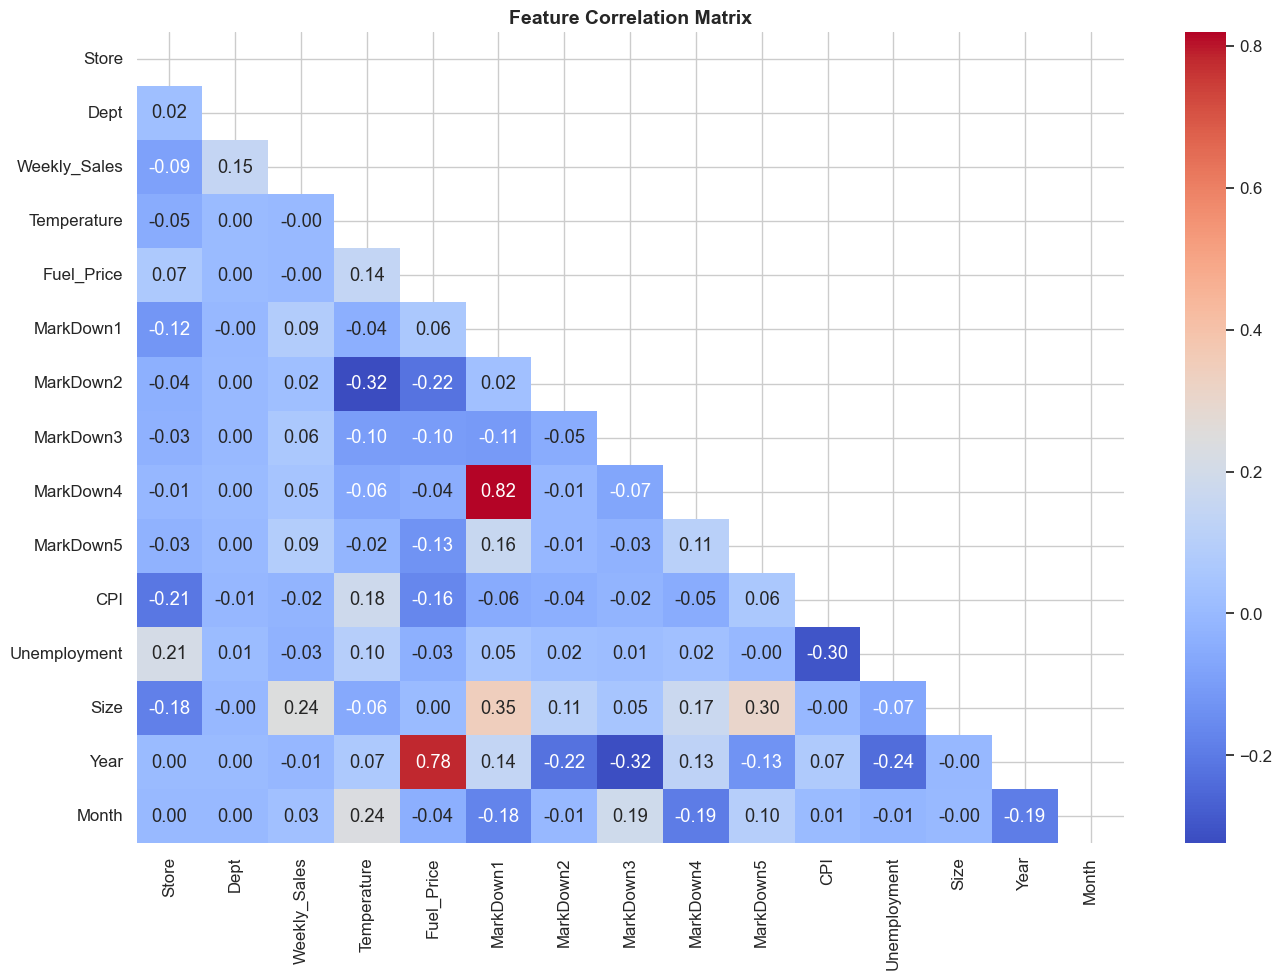

In [52]:
# Correlation Heatmap
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
corr = train_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs\fig_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Feature Engineering Function

In [53]:
def engineer_features(df, medians=None, last_sales=None, is_train=True):
    df = df.copy()

    #  Date features
    df['Date']  = pd.to_datetime(df['Date'])
    df['Year']  = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week']  = df['Date'].dt.isocalendar().week.astype(int)
    df['Day']   = df['Date'].dt.day

    #  Holiday proximity
    thanksgiving_date = pd.to_datetime(df['Year'].astype(str) + '-11-24')
    christmas_date    = pd.to_datetime(df['Year'].astype(str) + '-12-24')
    df['Days_to_Thanksgiving'] = (thanksgiving_date - df['Date']).dt.days.astype(int)
    df['Days_to_Christmas']    = (christmas_date    - df['Date']).dt.days.astype(int)

    #  Event flags
    df['SuperBowl']    = (df['Week'] == 6).astype(int)
    df['LaborDay']     = (df['Week'] == 36).astype(int)
    df['Thanksgiving'] = (df['Week'] == 47).astype(int)
    df['Christmas']    = (df['Week'] == 52).astype(int)
    df['BlackFriday']  = ((df['Month'] == 11) & (df['Week'].isin([47, 48]))).astype(int)

    #  Markdown features
    md_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    for col in md_cols:
        df[f'{col}_present'] = df[col].notna().astype(int)
    df[md_cols] = df[md_cols].fillna(0)
    df['MarkdownsSum']   = df[md_cols].sum(axis=1)
    df['MarkdownsCount'] = (df[md_cols] > 0).sum(axis=1)

    #  IsHoliday → int
    df['IsHoliday'] = df['IsHoliday'].astype(int)

    #  Store type encoding
    type_map = {'A': 1, 'B': 2, 'C': 3}
    df['TypeEncoded'] = df['Type'].map(type_map)

    #  Median baseline
    median_key = ['Type', 'Store', 'Dept', 'Month', 'IsHoliday']
    if is_train:
        medians = (df.groupby(median_key)['Weekly_Sales']
                     .median()
                     .reset_index()
                     .rename(columns={'Weekly_Sales': 'MedianSales'}))
    global_median = df['Weekly_Sales'].median() if is_train else medians['MedianSales'].median()
    df = df.merge(medians, on=median_key, how='left')
    df['MedianSales'] = df['MedianSales'].fillna(global_median)

    # ── Lagged sales ──
    if is_train:
        df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
        df['LaggedSales'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
        df['LaggedSales'] = df['LaggedSales'].fillna(df['MedianSales'])
        df['SalesDif']    = df['Weekly_Sales'] - df['MedianSales']

        last_sales = (df.sort_values('Date')
                        .groupby(['Store', 'Dept'])[['Date', 'Weekly_Sales']]
                        .last()
                        .reset_index()
                        .rename(columns={'Weekly_Sales': 'LaggedSales'}))
    else:
        df = df.merge(last_sales[['Store', 'Dept', 'LaggedSales']],
                      on=['Store', 'Dept'], how='left')
        df['LaggedSales'] = df['LaggedSales'].fillna(df['MedianSales'])

    # ── Fill remaining nulls ──
    for col in ['CPI', 'Unemployment']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mean())
    df = df.fillna(0)

    if is_train:
        return df, medians, last_sales
    return df


print('engineer_features() defined.')

engineer_features() defined.


In [54]:
# Apply
train_df, medians, last_sales = engineer_features(train_df, is_train=True)
test_df  = engineer_features(test_df, medians=medians, last_sales=last_sales, is_train=False)

print(f'Train after FE : {train_df.shape}')
print(f'Test  after FE : {test_df.shape}')

Train after FE : (421570, 38)
Test  after FE : (115064, 36)


## 8. Train / Validation Split → Encoding & Scaling (No Data Leakage)

In [55]:
FEATURE_COLS = [
    'Store', 'Dept', 'TypeEncoded', 'Size', 'Year', 'Month', 'Week', 'Day', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'MarkDown1_present', 'MarkDown2_present', 'MarkDown3_present',
    'MarkDown4_present', 'MarkDown5_present', 'MarkdownsSum', 'MarkdownsCount', 'IsHoliday', 'Days_to_Thanksgiving', 'Days_to_Christmas',
    'SuperBowl', 'LaborDay', 'Thanksgiving', 'Christmas', 'BlackFriday', 'MedianSales', 'LaggedSales',]

TARGET = 'Weekly_Sales'

FEATURE_COLS = [f for f in FEATURE_COLS if f in train_df.columns]

X = train_df[FEATURE_COLS].copy()
y = train_df[TARGET].copy()
X_test = test_df[FEATURE_COLS].copy()

#  20% of data as validation
val_split = int(len(X) * 0.8)
X_train, X_val = X.iloc[:val_split], X.iloc[val_split:]
y_train, y_val = y.iloc[:val_split], y.iloc[val_split:]

print(f'Train samples : {len(X_train):,}')
print(f'Val   samples : {len(X_val):,}')
print(f'Test  samples : {len(X_test):,}')
print(f'Features      : {len(FEATURE_COLS)}')

Train samples : 337,256
Val   samples : 84,314
Test  samples : 115,064
Features      : 34


In [56]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLS)

## 9. Save Processed Data & Artifacts

In [57]:
os.makedirs('data_processed', exist_ok=True)

# Save splits
X_train_scaled.to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/X_train.parquet', index=False)
X_val_scaled.to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/X_val.parquet',   index=False)
X_test_scaled.to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/X_test.parquet',  index=False)
y_train.to_frame().to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/y_train.parquet', index=False)
y_val.to_frame().to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/y_val.parquet',   index=False)

# Save IsHoliday for WMAE
train_df.loc[X_val.index, ['IsHoliday']].to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/holiday_val.parquet', index=False)

# Save test metadata for submission
test_df[['Store', 'Dept', 'Date']].to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/test_meta.parquet', index=False)

# Save preprocessing
joblib.dump(scaler,r'C:\Users\User\Desktop\project\models/scaler.pkl')
joblib.dump(medians,r'C:\Users\User\Desktop\project\models/medians.pkl')
joblib.dump(last_sales,r'C:\Users\User\Desktop\project\models/last_sales.pkl')
joblib.dump(FEATURE_COLS,r'C:\Users\User\Desktop\project\models/feature_cols.pkl')

# Save full merged DataFrames for notebook 2
train_df.to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/train_full.parquet', index=False)
test_df.to_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/test_full.parquet',  index=False)

print(' All data_processed saved to ./data_processed/')
print(os.listdir('data_processed'))

 All data_processed saved to ./data_processed/
['test_meta.parquet']
